# Fig 6A & 6D — mC vs 3C agreement (ARI + Mus-Skl confusion)

For each major type, we independently sub-clustered its cells from **CG methylation** and
from **chromatin contacts**, then measured how much the two label sets agree with the
**adjusted Rand index (ARI)**. Low ARI = the two modalities disagree on subtype identity —
the phenomenon Fig 6 dissects. (Source: `clustering/merged/L2_hiconly/summary.ipynb`.)

## 📥 Required input files

- `{ENTEX_ROOT}/L1color.tsv` · _metadata: major-type color/annotation_
- `{ENTEX_ROOT}/clustering/merged/L2_hiconly/{L1}/mergemcg_rocpr.npy` · _mC subtype labels_
- `{ENTEX_ROOT}/clustering/merged/L2_hiconly/{L1}/mergehic_rocpr.npy` · _3C subtype labels_

In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

[repro_guard] active — READ-ONLY (all writes skipped; inline figures still render)


In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score as ARI

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

indir = f'{ENTEX_ROOT}/clustering/merged/'
L1_meta = pd.read_csv(f'{ENTEX_ROOT}/L1color.tsv', sep='\t', header=0, index_col=0)

In [3]:
# ARI between the mC-based and 3C-based subtype labels, per major type.
# (Only the two label vectors are needed; the per-type embedding h5ads are not.)
score = {}
for l1 in L1_meta.index:
    l1_name = L1_meta.loc[l1, 'L1_abbr'].replace(' ', '-').replace('/', '_')
    fmc  = f'{indir}L2_hiconly/{l1_name}/mergemcg_rocpr.npy'
    fhic = f'{indir}L2_hiconly/{l1_name}/mergehic_rocpr.npy'
    if not (os.path.exists(fmc) and os.path.exists(fhic)):
        continue
    labelmc = np.load(fmc,  allow_pickle=True)
    label3c = np.load(fhic, allow_pickle=True)
    score[l1] = ARI(labelmc, label3c)

score = pd.Series(score).sort_values()
print(f'{score.shape[0]} major types; lowest ARI:', score.index[0], round(score.iloc[0], 3))

35 major types; lowest ARI: c22 0.006


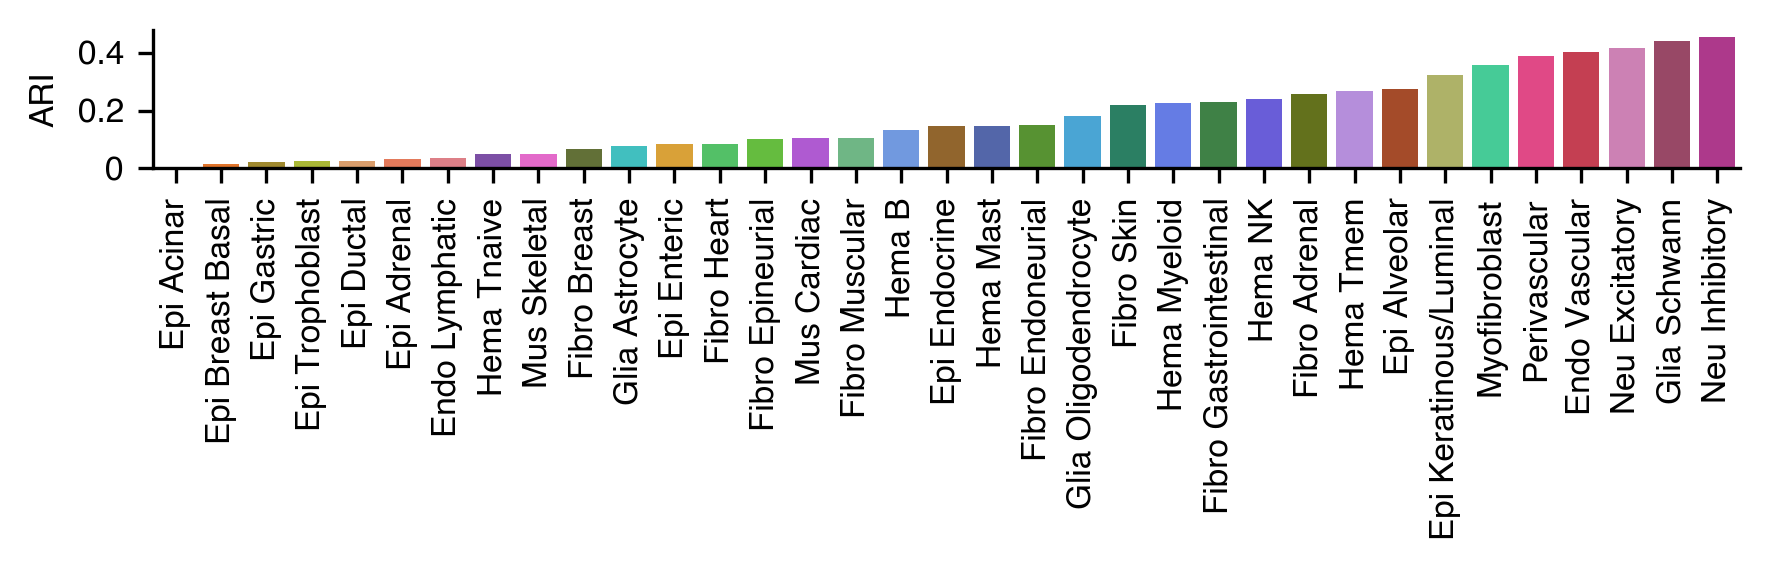

In [4]:
nct = score.shape[0]
xticks = np.arange(nct)

fig, ax = plt.subplots(figsize=(6, 2), dpi=300)
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.bar(x=xticks, height=score, color=L1_meta.loc[score.index, 'color'], width=0.8)

ax.set_xticks(xticks)
ax.set_xticklabels(L1_meta.loc[score.index, 'L1_annot'], fontsize=8, rotation=90)
ax.set_xlim([-0.5, nct - 0.5])
ax.set_yticks([0, 0.2, 0.4])
ax.set_yticklabels([0, 0.2, 0.4], fontsize=8)
ax.set_ylabel('ARI', fontsize=8)
fig.tight_layout()
fig.savefig('clustering/merged/L2_hiconly/mc_3c_L2_ARI.pdf', transparent=True)   # Fig 6A

## Fig 6D — Mus-Skl donor-corrected mC-vs-3C confusion

For skeletal muscle, cross-tabulate the **donor-corrected** methylation-based (`leiden_group_mc`)
vs contact-based (`leiden_group_3c`) group labels (from the donor-clustering step, `fig6/02`).

leiden_group_3c  3c0   3c1   3c2
leiden_group_mc                 
mc0              135   291   184
mc1                1  1271    88
mc2                4   173  1826


/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


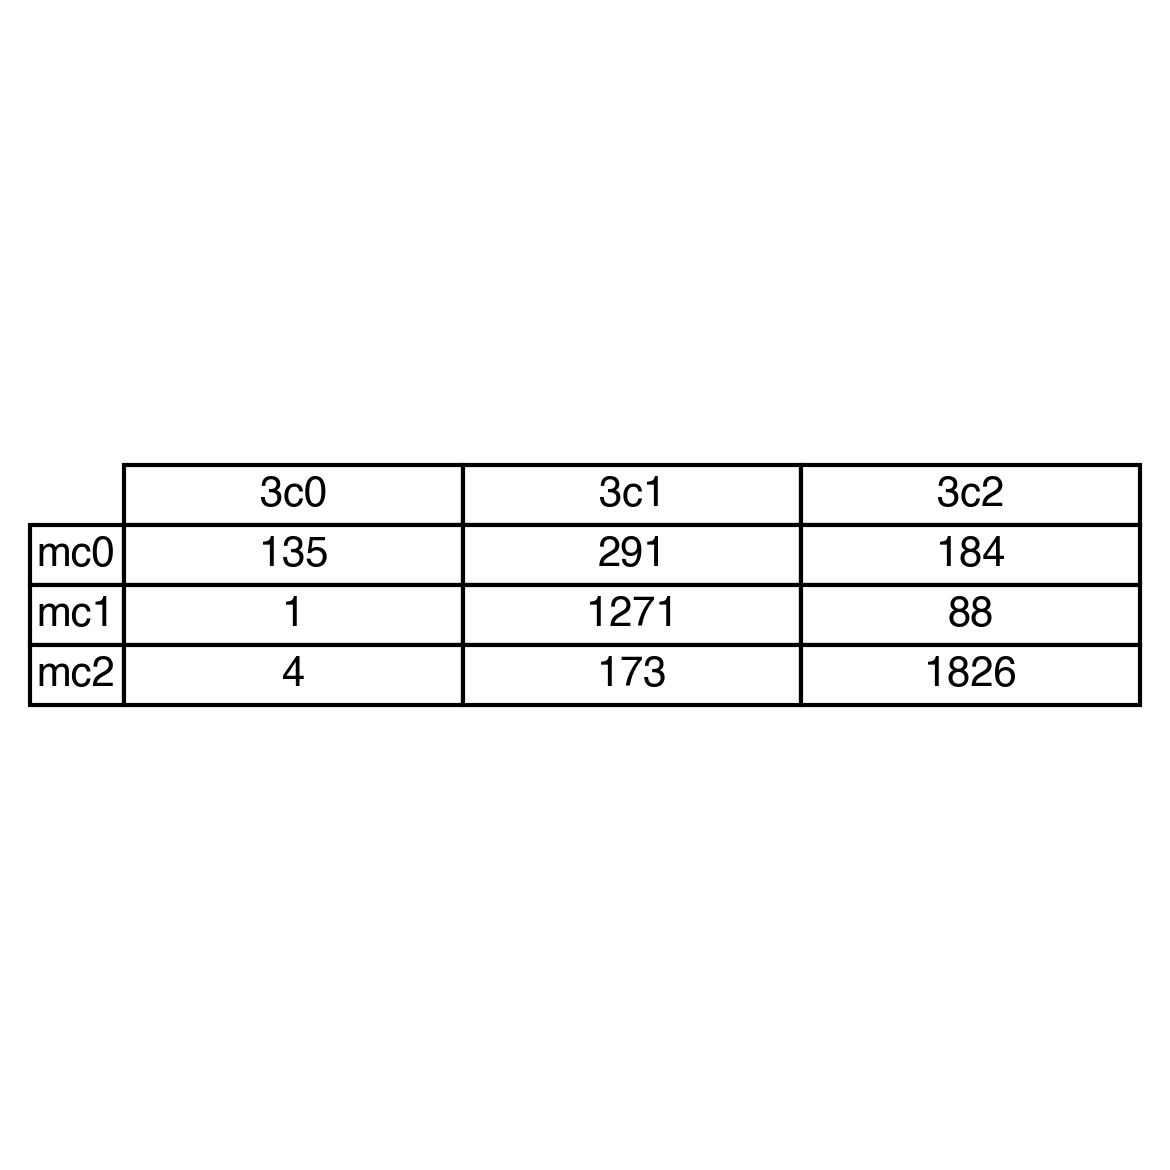

In [5]:
import anndata
obs = anndata.read_h5ad(f'{ENTEX_ROOT}/analysis/Mus-Skl/5kCG100k3C_embed_new.h5ad', backed='r').obs
count = pd.crosstab(obs['leiden_group_mc'], obs['leiden_group_3c'])
count = count.reindex(index=sorted(count.index), columns=sorted(count.columns))
print(count)

fig, ax = plt.subplots(figsize=(4, 4), dpi=300)
ax.table(cellText=count.values, cellLoc='center', loc='center', rowLoc='right',
         rowLabels=count.index, colLabels=count.columns)
ax.axis('off')
fig.tight_layout()
fig.savefig('Mus-Skl/mc3c_confusion_donor.pdf', transparent=True)  # Fig 6D
